# Plastic Bottle Waste Detection — YOLOv8

Deteksi sampah botol plastik menggunakan **YOLOv8 Small** melalui framework **Ultralytics**.

| Informasi | Detail |
|-----------|--------|
| Model | YOLOv8s (11.2M parameters, mAP@50 ~0.92) |
| Dataset | Plastic Bottle Waste Detection (1 class: `bottle`) |
| Split | Train: 2177 · Valid: 1174 · Test: 648 |
| Hardware | NVIDIA RTX 3050 (6 GB VRAM) |

---

## Tahap 1 — Persiapan Environment

Memastikan semua dependencies terinstall dan GPU terdeteksi dengan benar.

In [ ]:
# Install dependencies (jalankan sekali jika belum terinstall)
#!pip install ultralytics opencv-python matplotlib pandas seaborn

In [1]:
import torch
import ultralytics

print(f"Python       : {__import__('sys').version}")
print(f"PyTorch      : {torch.__version__}")
print(f"Ultralytics  : {ultralytics.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️ CUDA tidak tersedia — training akan berjalan di CPU (sangat lambat)")

Python       : 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
PyTorch      : 2.6.0+cu124
Ultralytics  : 8.4.75
CUDA available: True
GPU          : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM         : 6.0 GB


---
## Tahap 2 — Persiapan Dataset

Verifikasi struktur dataset, jumlah gambar vs label, dan visualisasi sampel.

In [2]:
import os

dataset_root = "../datasets"
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset_root, split, "images")
    lbl_dir = os.path.join(dataset_root, split, "labels")
    img_count = len([f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXT)])
    lbl_count = len([f for f in os.listdir(lbl_dir) if f.lower().endswith('.txt')])
    status = "✅" if img_count == lbl_count else "❌ MISMATCH"
    print(f"{split:5s}: {img_count:5d} images, {lbl_count:5d} labels  {status}")

train:  2177 images,  2177 labels  ✅
valid:  1174 images,  1174 labels  ✅
test :   648 images,   648 labels  ✅


In [3]:
# Cek isi data.yaml
import yaml

with open(os.path.join(dataset_root, "data.yaml"), "r") as f:
    data_cfg = yaml.safe_load(f)

print("Isi data.yaml:")
for k, v in data_cfg.items():
    print(f"  {k}: {v}")

Isi data.yaml:
  train: ./train/images
  val: ./valid/images
  test: ./test/images
  nc: 1
  names: ['bottle']


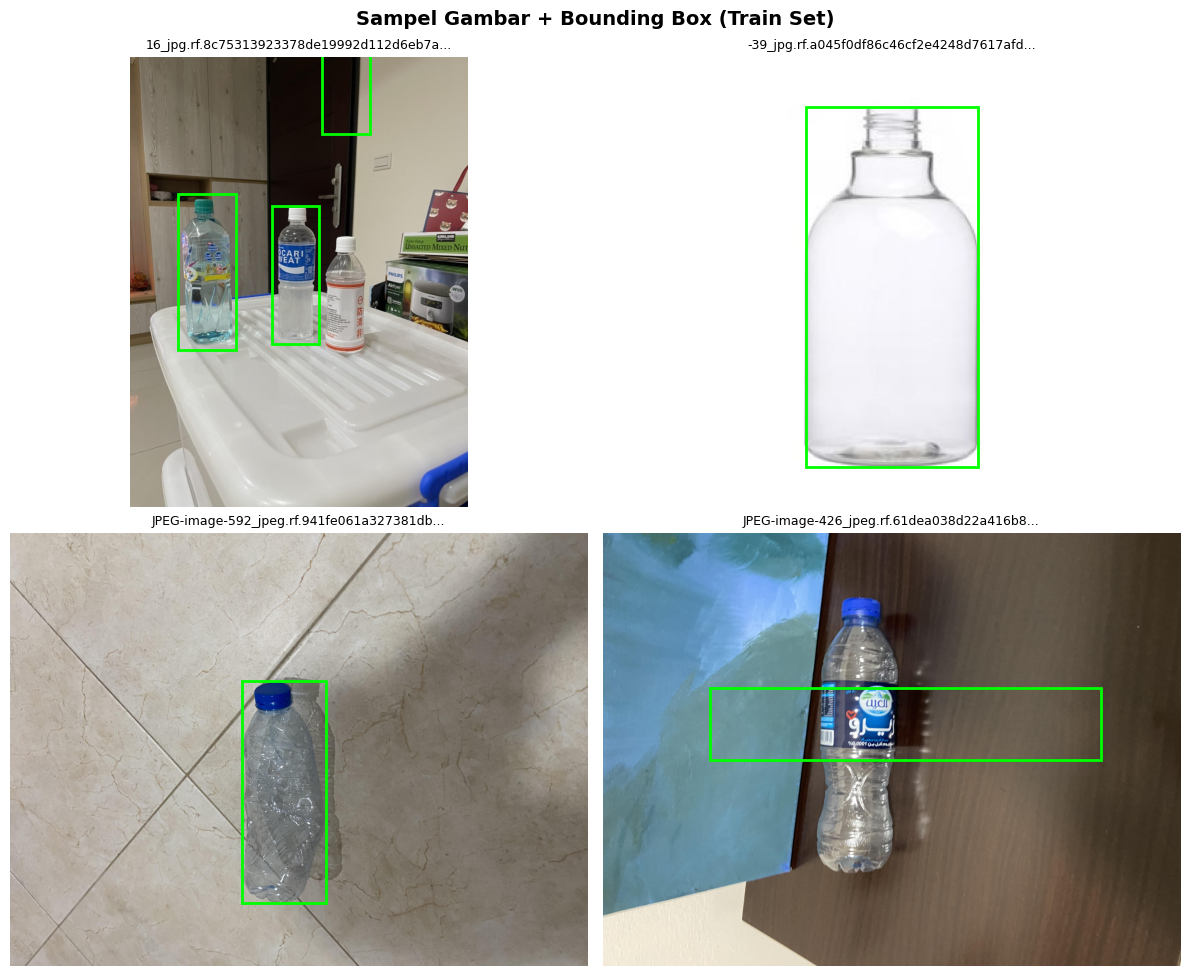

In [4]:
# Visualisasi sampel gambar + bounding box
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

random.seed(42)

split = "train"
img_files = sorted(os.listdir(os.path.join(dataset_root, split, "images")))
samples = random.sample(img_files, 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Sampel Gambar + Bounding Box (Train Set)", fontsize=14, fontweight="bold")

for ax, fname in zip(axes.flat, samples):
    img_path = os.path.join(dataset_root, split, "images", fname)
    lbl_path = os.path.join(dataset_root, split, "labels", os.path.splitext(fname)[0] + ".txt")

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img_rgb)

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=2, edgecolor="lime", facecolor="none"
                )
                ax.add_patch(rect)

    ax.set_title(fname[:40] + "...", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

Total objek di train set: 3186
Rata-rata bbox width : 0.349  (std: 0.241)
Rata-rata bbox height: 0.571  (std: 0.291)


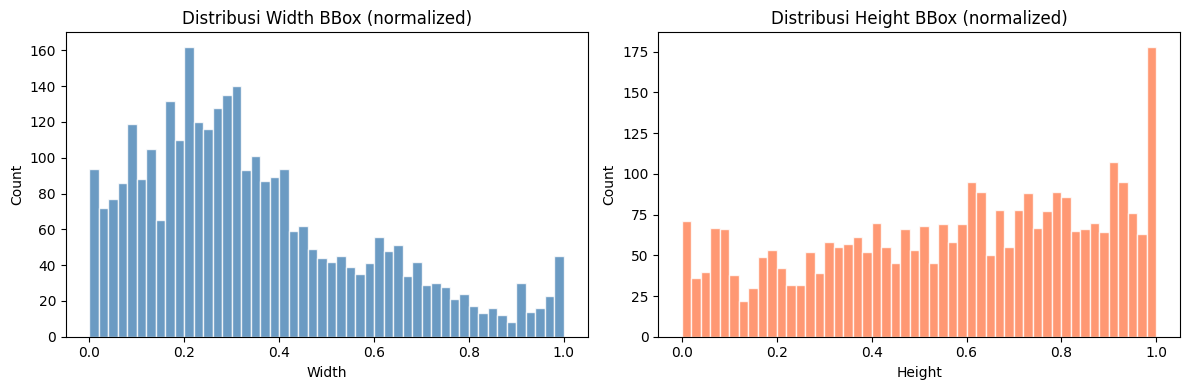

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

widths, heights = [], []
lbl_dir = os.path.join(dataset_root, "train", "labels")

for lbl_file in os.listdir(lbl_dir):
    if not lbl_file.endswith('.txt'): # Skip file selain .txt (jika ada)
        continue
    with open(os.path.join(lbl_dir, lbl_file), "r") as f:
        for line in f:
            parts = line.strip().split()
            # Pastikan baris memiliki minimal 5 kolom (format YOLO standar)
            if len(parts) >= 5:
                try:
                    # Ambil width (index 3) dan height (index 4)
                    bw = float(parts[3])
                    bh = float(parts[4])
                    widths.append(bw)
                    heights.append(bh)
                except ValueError:
                    # Abaikan baris jika ada data yang bukan angka
                    continue

print(f"Total objek di train set: {len(widths)}")
print(f"Rata-rata bbox width : {np.mean(widths):.3f}  (std: {np.std(widths):.3f})")
print(f"Rata-rata bbox height: {np.mean(heights):.3f}  (std: {np.std(heights):.3f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax1.set_title("Distribusi Width BBox (normalized)")
ax1.set_xlabel("Width")
ax1.set_ylabel("Count")

ax2.hist(heights, bins=50, color="coral", edgecolor="white", alpha=0.8)
ax2.set_title("Distribusi Height BBox (normalized)")
ax2.set_xlabel("Height")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## Tahap 3 — Training Model

Training menggunakan YOLOv8s dengan konfigurasi yang dioptimasi untuk RTX 3050 (6 GB VRAM).

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| model | yolov8s.pt | Pre-trained small variant |
| epochs | 100 | Dengan early stopping (patience=15) |
| imgsz | 640 | Standar, keseimbangan akurasi vs kecepatan |
| batch | 16 | Muat di VRAM 6 GB |
| device | 0 (GPU) | RTX 3050 |

In [6]:
from ultralytics import YOLO

# Load pre-trained YOLOv8s
model = YOLO("yolov8s.pt")
model.info()

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(129, 11166560, 0, 28.816844800000002)

In [7]:
# Training
results = model.train(
    data="../datasets/data.yaml",
    resume=True,
    epochs=100,
    imgsz=640,
    batch=-1,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=4,
    patience=30,
    project="../runs/detect",
    name="train_bottle",
    pretrained=True,
    optimizer="auto",
    verbose=True,
    seed=42,
    deterministic=True,
    cos_lr=True,        # cosine LR schedule, biasanya +0.5–1% mAP
    lr0=0.01,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    label_smoothing=0.1,# bantu generalisasi
    close_mosaic=15,    # matikan mosaic 15 epoch terakhir (default 10)
    cache='disk',       # speed-up: cache label di disk
    exist_ok=True,      # izinkan re-run tanpa bikin train_bottle2, train_bottle3
)

WARNING model 'yolov8s.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.75  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=../datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False

KeyboardInterrupt: 

In [ ]:
# Tampilkan training loss curves
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_img = mpimg.imread("../runs/detect/train_bottle/results.png")
plt.figure(figsize=(14, 8))
plt.imshow(results_img)
plt.axis("off")
plt.title("Training Results — Loss & Metrics Curves")
plt.tight_layout()
plt.show()

---
## Tahap 4 — Evaluasi Model

Evaluasi model terbaik pada test set untuk mendapatkan metrik final.

In [ ]:
from ultralytics import YOLO

# Load best model
best_model = YOLO("../runs/detect/train_bottle/weights/best.pt")

# Evaluasi pada test set
metrics = best_model.val(
    data="../datasets/data.yaml", 
    split="test",
    conf=0.001,   # standar COCO eval
    iou=0.6,      # NMS IoU threshold
    plots=True,   # otomatis simpan PR/F1/CM
    )

print("=" * 45)
print("  HASIL EVALUASI — TEST SET")
print("=" * 45)
print(f"  Precision  : {metrics.box.mp:.4f}   (target ≥ 0.85)")
print(f"  Recall     : {metrics.box.mr:.4f}   (target ≥ 0.85)")
print(f"  mAP@50     : {metrics.box.map50:.4f}   (target ≥ 0.90)")
print(f"  mAP@50-95  : {metrics.box.map:.4f}   (target ≥ 0.60)")
print("=" * 45)

In [ ]:
# Tampilkan confusion matrix
import matplotlib.image as mpimg

cm_img = mpimg.imread("../runs/detect/train_bottle/confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(cm_img)
plt.axis("off")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

In [ ]:
# Tampilkan precision-recall curve dan F1 curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pr_img = mpimg.imread("../runs/detect/train_bottle/PR_curve.png")
f1_img = mpimg.imread("../runs/detect/train_bottle/F1_curve.png")

axes[0].imshow(pr_img)
axes[0].set_title("Precision-Recall Curve")
axes[0].axis("off")

axes[1].imshow(f1_img)
axes[1].set_title("F1 Curve")
axes[1].axis("off")

plt.tight_layout()
plt.show()

---
## Tahap 5 — Inferensi & Implementasi

Menggunakan model terbaik untuk deteksi pada gambar, video, dan webcam.

In [ ]:
from ultralytics import YOLO

# Load best model untuk inferensi
model = YOLO("../runs/detect/train_bottle/weights/best.pt")

### 5.1 Deteksi pada Gambar

In [ ]:
import os
import random

# Ambil beberapa gambar acak dari test set untuk demo
test_img_dir = "../datasets/test/images"
test_images = sorted(os.listdir(test_img_dir))
demo_images = random.sample(test_images, min(6, len(test_images)))

for img_name in demo_images:
    img_path = os.path.join(test_img_dir, img_name)
    results = model.predict(source=img_path, conf=0.5, save=False, verbose=False)

    # Tampilkan hasil
    annotated = results[0].plot()  # BGR image with annotations
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    n_detections = len(results[0].boxes)
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated_rgb)
    plt.title(f"{img_name} — {n_detections} bottle(s) detected")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# Deteksi batch pada seluruh test set — simpan hasilnya
results = model.predict(
    source="../datasets/test/images",
    conf=0.5,
    save=True,
    project="../runs/detect",
    name="predict_test_set",
    verbose=True,
)

print(f"\nTotal gambar diproses: {len(results)}")
total_bottles = sum(len(r.boxes) for r in results)
print(f"Total botol terdeteksi: {total_bottles}")

### 5.2 Deteksi pada Video

> **Catatan:** Siapkan file video di path yang sesuai, atau gunakan webcam sebagai sumber video.

In [ ]:
# Deteksi pada video (ubah path sesuai file video yang tersedia)
# video_path = "path/to/video.mp4"  # <-- Ganti dengan path video Anda

# results = model.predict(
#     source=video_path,
#     conf=0.5,
#     save=True,
#     project="../runs/detect",
#     name="predict_video",
# )

print("Untuk menjalankan deteksi video:")
print("1. Uncomment kode di atas")
print("2. Ganti video_path dengan path file video Anda")
print("3. Jalankan cell")

### 5.3 Deteksi Real-time via Webcam

In [ ]:
import cv2
from ultralytics import YOLO

model = YOLO("../runs/detect/train_bottle/weights/best.pt")

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("❌ Tidak bisa membuka webcam")
else:
    print("🎥 Webcam aktif — tekan 'q' untuk keluar")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Deteksi
        results = model.predict(source=frame, conf=0.5, verbose=False)

        # Ambil frame yang sudah dianotasi
        annotated_frame = results[0].plot()

        # Hitung jumlah botol terdeteksi
        n_bottles = len(results[0].boxes)

        # Tampilkan counter di frame
        cv2.putText(
            annotated_frame,
            f"Bottles: {n_bottles}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2,
        )

        cv2.imshow("Plastic Bottle Detection", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam ditutup.")

### 5.4 Export Model

Export model ke format ONNX agar bisa dijalankan di perangkat tanpa GPU / untuk deployment.

In [ ]:
# Export ke ONNX format
model = YOLO("../runs/detect/train_bottle/weights/best.pt")

model.export(
    format="onnx",
    imgsz=640,
    simplify=True,
    dynamic=True,   # ← mendukung dynamic batch size
    opset=14,       # ← kompatibilitas lebih luas
    half=False,     # set True jika target mendukung FP16

)

print("✅ Model berhasil di-export ke format ONNX")

---
## Ringkasan

| Tahap | Status | Output |
|-------|--------|--------|
| 1. Persiapan Environment | ✅ | Python, PyTorch, Ultralytics YOLOv8 |
| 2. Persiapan Dataset | ✅ | Dataset terverifikasi (2177/1174/648) |
| 3. Training Model | ✅ | Best weights: `runs/detect/train_bottle/weights/best.pt` |
| 4. Evaluasi Model | ✅ | Precision, Recall, mAP@50, mAP@50-95 |
| 5. Inferensi | ✅ | Deteksi gambar, video, webcam + export ONNX |